In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/tradebook.csv')
df

,Ticker,Entry Time,Exit Time,Entry Price,Exit Price,PnL,Exit Reason,Cumulative PnL,Direction
0,ADANIENT,2015-02-03 12:15:00,2015-02-03 13:15:00,642.285765,645.561744,-710.050000,Stop Loss,-710.050000,short
1,ADANIENT,2015-02-04 11:15:00,2015-02-04 14:15:00,651.765170,648.441494,-709.950000,Stop Loss,-1420.000000,long
2,ADANIENT,2015-02-09 11:15:00,2015-02-09 14:15:00,629.087085,610.275494,2790.300000,Take Profit,1370.300000,short
3,ADANIENT,2015-02-16 11:15:00,2015-02-16 15:15:00,675.432450,666.066600,1186.644956,EOD Close,2556.944956,short
4,ADANIENT,2015-02-19 09:15:00,2015-02-19 13:15:00,671.667160,668.241993,-709.950000,Stop Loss,1846.994956,long
...,...,...,...,...,...,...,...,...,...
54607,WIPRO,2024-10-30 09:15:00,2024-10-30 15:15:00,562.556250,566.443350,490.970903,EOD Close,528635.055772,long
54608,WIPRO,2024-10-31 10:15:00,2024-10-31 15:15:00,554.094585,553.155310,-30.484718,EOD Close,528604.571055,short
54609,WIPRO,2024-11-04 09:15:00,2024-11-04 11:15:00,550.944900,534.469995,2790.300000,Take Profit,531394.871055,short
54610,WIPRO,2024-11-06 09:15:00,2024-11-06 14:15:00,547.504745,563.873494,2789.700000,Take Profit,534184.571055,long


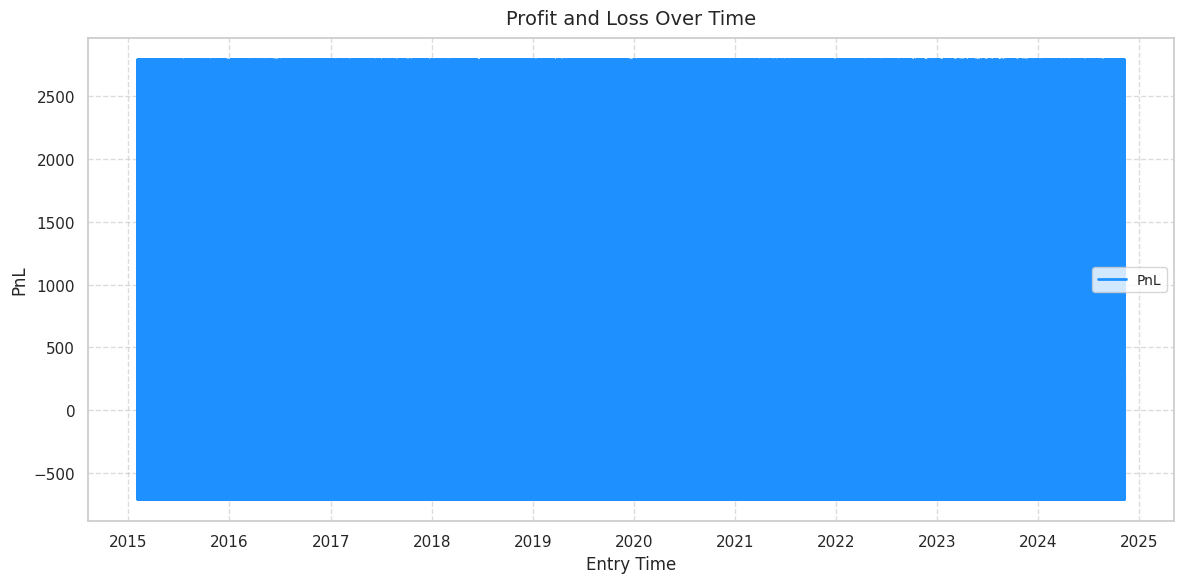

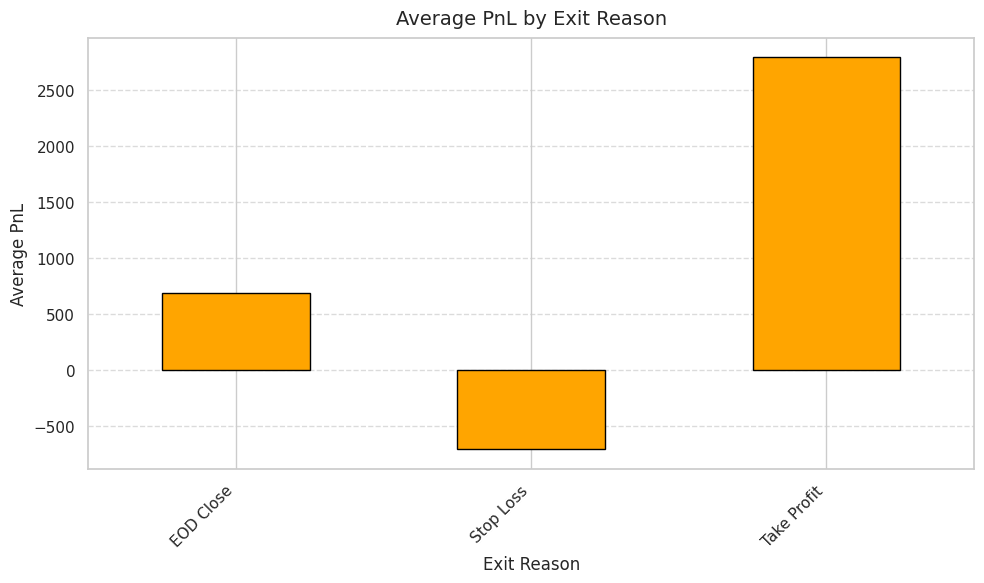

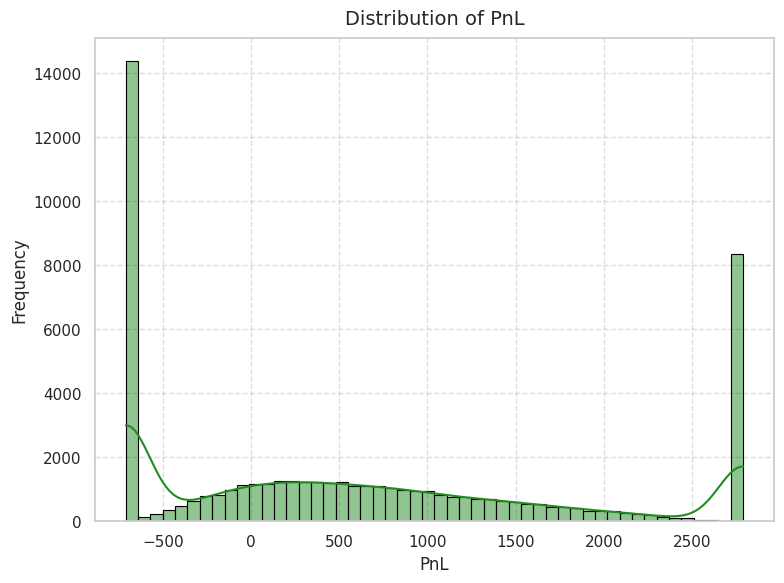

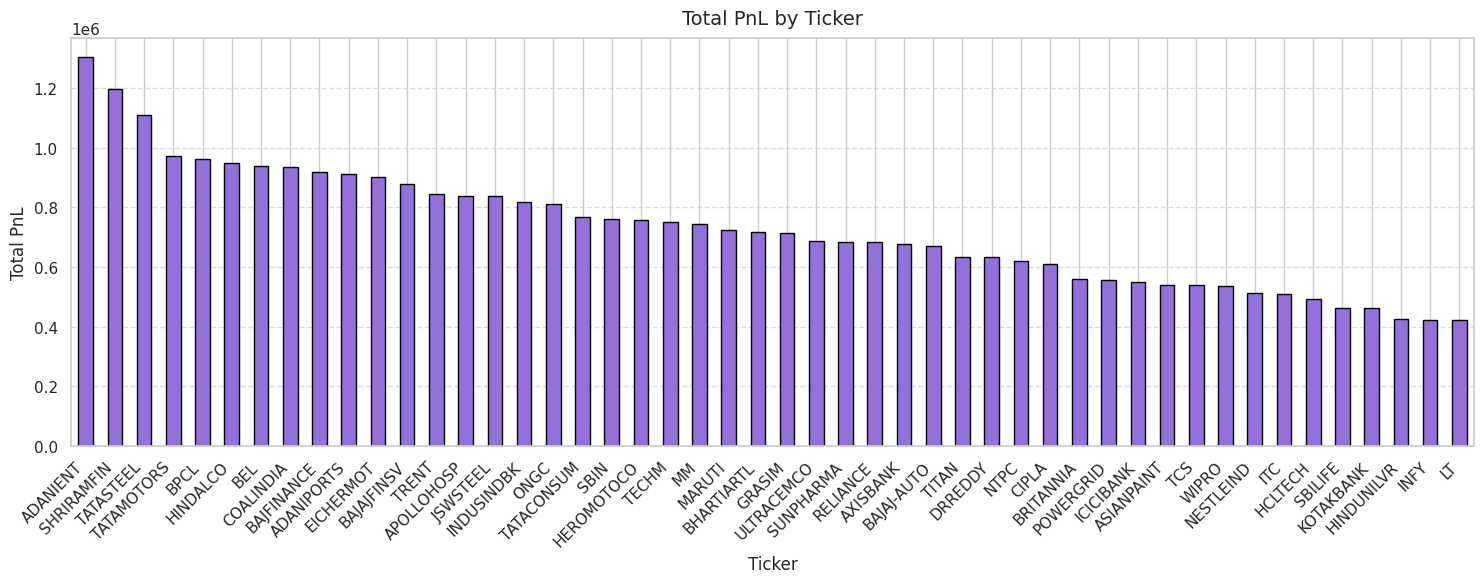

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set Seaborn style for consistent Matplotlib aesthetics
sns.set(style='whitegrid')

# Prepare the DataFrame: Convert datetime columns and sort by 'Entry Time'
df = df.copy()  # Avoid modifying the original DataFrame directly
df['Entry Time'] = pd.to_datetime(df['Entry Time'], format='%Y-%m-%d %H:%M:%S')
df['Exit Time'] = pd.to_datetime(df['Exit Time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values('Entry Time')

# --- Visualization 1: Line Plot for PnL Over Time ---
plt.figure(figsize=(12, 6))
plt.plot(df['Entry Time'], df['PnL'], color='dodgerblue', label='PnL', linewidth=2)
plt.title('Profit and Loss Over Time', fontsize=14, pad=10)
plt.xlabel('Entry Time', fontsize=12)
plt.ylabel('PnL', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualization 2: Bar Plot for Average PnL by Exit Reason ---
plt.figure(figsize=(10, 6))
avg_pnl_exit = df.groupby('Exit Reason')['PnL'].mean()
avg_pnl_exit.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average PnL by Exit Reason', fontsize=14, pad=10)
plt.xlabel('Exit Reason', fontsize=12)
plt.ylabel('Average PnL', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Visualization 3: Histogram for PnL Distribution ---
plt.figure(figsize=(8, 6))
sns.histplot(df['PnL'], kde=True, bins=50, color='forestgreen', edgecolor='black')
plt.title('Distribution of PnL', fontsize=14, pad=10)
plt.xlabel('PnL', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualization 5: Interactive Trade Summary by Ticker ---
def plot_trade_summary(tradebook_df):
    tradebook_df = tradebook_df.copy()
    tradebook_df['Win'] = tradebook_df['PnL'] > 0
    tradebook_df['Loss'] = tradebook_df['PnL'] < 0

    summary = tradebook_df.groupby('Ticker').agg(
        Total_Trades=('Ticker', 'count'),
        Winning_Trades=('Win', 'sum'),
        Losing_Trades=('Loss', 'sum')
    ).reset_index()

    summary_melted = summary.melt(
        id_vars='Ticker',
        value_vars=['Winning_Trades', 'Losing_Trades'],
        var_name='Trade Type',
        value_name='Count'
    )

    fig = px.bar(
        summary_melted,
        x='Ticker',
        y='Count',
        color='Trade Type',
        barmode='group',
        title='Trade Summary by Ticker',
        labels={'Count': 'Number of Trades', 'Ticker': 'Stock Ticker'},
        text_auto=True,
        color_discrete_map={'Winning_Trades': 'green', 'Losing_Trades': 'red'}
    )
    fig.update_layout(
        xaxis_tickangle=-45,
        title_font_size=16,
        xaxis_title_font_size=14,
        yaxis_title_font_size=14,
        legend_title_text='Trade Outcome'
    )
    fig.show()

plot_trade_summary(df)

# --- Visualization 6: Bar Plot for Sum of PnL by Ticker ---
pnl_by_ticker = df.groupby('Ticker')['PnL'].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 6))
pnl_by_ticker.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Total PnL by Ticker', fontsize=14, pad=10)
plt.xlabel('Ticker', fontsize=12)
plt.ylabel('Total PnL', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Visualization 7: Interactive PnL by Weekday ---
df['Weekday'] = df['Exit Time'].dt.day_name()
weekday_pnl = df.groupby('Weekday')['PnL'].sum().reset_index()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_pnl['Weekday'] = pd.Categorical(weekday_pnl['Weekday'], categories=weekday_order, ordered=True)
weekday_pnl = weekday_pnl.sort_values('Weekday')
weekday_pnl['PnL_Type'] = weekday_pnl['PnL'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

fig = px.bar(
    weekday_pnl,
    x='Weekday',
    y='PnL',
    title='Total PnL by Weekday',
    labels={'PnL': 'Total PnL', 'Weekday': 'Day of Week'},
    color='PnL_Type',
    color_discrete_map={'Positive': 'green', 'Negative': 'red'},
    text_auto=True
)
fig.update_layout(
    title_font_size=16,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    legend_title_text='PnL Type'
)
fig.show()

In [32]:
import plotly.graph_objects as go
import pandas as pd

# Assuming 'df' has already been sorted and includes 'PnL'
df = df.sort_values('Entry Time')
df['Cumulative PnL'] = df['PnL'].cumsum()
df['Peak'] = df['Cumulative PnL'].cummax()
df['Drawdown'] = ((df['Cumulative PnL'] - df['Peak']) / 1000000) * 100# As percent

# Create figure with subplots
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Portfolio Balance Over Time", "Drawdown (%)")
)

# 1. Balance Over Time
fig.add_trace(
    go.Scatter(x=df['Entry Time'], y=df['Cumulative PnL'], mode='lines', name='Balance', line=dict(color='purple')),
    row=1, col=1
)

# 2. Drawdown Percentage
fig.add_trace(
    go.Scatter(x=df['Entry Time'], y=df['Drawdown'], mode='lines', name='Drawdown %', line=dict(color='red')),
    row=2, col=1
)

# Update layout
fig.update_layout(
    height=700,
    width=1000,
    title_text="Portfolio Performance Overview (Interactive)",
    showlegend=True,
    template='plotly_white'
)

# Axis labels
fig.update_yaxes(title_text="Balance", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
fig.update_xaxes(title_text="Entry Time", row=2, col=1)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Convert 'Entry Time' to datetime
df['Entry Time'] = pd.to_datetime(df['Entry Time'])

# Extract year-month
df['YearMonth'] = df['Entry Time'].dt.to_period('M')

# Convert PnL to percentage based on ₹1,00,000 capital
df['PnL %'] = (df['PnL'] / 100000) * 100

# Group by Ticker and Month, then pivot
pnl_pct_matrix = df.groupby(['Ticker', 'YearMonth'])['PnL %'].sum().unstack().fillna(0)
pnl_pct_matrix.columns = pnl_pct_matrix.columns.astype(str)

pnl_pct_matrix.to_csv("monthly_pnl_percentage_matrix.csv")

# Create red-white-green colormap centered at 0
cmap = mcolors.LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"])

# Find the max absolute value for symmetrical color scaling
vmax = abs(pnl_pct_matrix.values).max()

# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(pnl_pct_matrix, annot=True, fmt=".2f", cmap=cmap, center=0,
            vmin=-vmax, vmax=vmax, linewidths=0.1, linecolor='gray', annot_kws={"size": 10})

plt.title('Monthly PnL % per Ticker (₹1L capital)', fontsize=20, pad=5)
plt.xlabel('Month')
plt.ylabel('Ticker')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime format
df['Entry Time'] = pd.to_datetime(df['Entry Time'])

# Monthly return % based on ₹1L capital
df['YearMonth'] = df['Entry Time'].dt.to_period('M')
df['PnL %'] = (df['PnL'] / 100000) * 100

# Group by Ticker and Month, sum PnL % for monthly returns
monthly_returns = df.groupby(['Ticker', 'YearMonth'])['PnL %'].sum().reset_index()

# Pivot: Ticker x Month
returns_matrix = monthly_returns.pivot(index='Ticker', columns='YearMonth', values='PnL %').sort_index(axis=1)

# Compute rolling Sharpe (mean / std over 3 months)
rolling_mean = returns_matrix.rolling(window=3, axis=1).mean()
rolling_std = returns_matrix.rolling(window=3, axis=1).std()
rolling_sharpe = rolling_mean / rolling_std

rolling_sharpe.to_csv("rolling_3M_sharpe_ratio.csv")

# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(rolling_sharpe, annot=True, fmt=".2f", cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Rolling 3M Sharpe'}, annot_kws={"size": 10})
plt.title('Rolling 3-Month Sharpe Ratio per Ticker', fontsize=16, pad=12)
plt.xlabel('Month')
plt.ylabel('Ticker')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [35]:
import pandas as pd
import plotly.express as px

# Load the tradebook DataFrame
tradebook = df

# Convert 'Entry Time' to datetime if not already
tradebook['Entry Time'] = pd.to_datetime(tradebook['Entry Time'])

# Define the start and end time for the trading session
start_time = pd.Timestamp("09:15:00")
end_time = pd.Timestamp("15:30:00")

# Create a function to assign time slots
def assign_time_slot(entry_time):
    minutes_since_start = (entry_time - start_time).seconds // 60
    slot_number = minutes_since_start // 10
    slot_start_time = start_time + pd.Timedelta(minutes=slot_number * 10)
    slot_end_time = slot_start_time + pd.Timedelta(minutes=10)
    return f"{slot_start_time.time()} - {slot_end_time.time()}"

# Apply the function to create time slots
tradebook['Time Slot'] = tradebook['Entry Time'].apply(assign_time_slot)

# Create a new column to categorize PnL as positive or negative
tradebook['PnL Category'] = tradebook['PnL'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Define a color map for positive and negative PnL
color_map = {
    'Positive': 'green',
    'Negative': 'red'
}

# Create a scatter plot using Plotly
fig = px.scatter(
    tradebook,
    x='Time Slot',  # Use the 'Time Slot' column for x-axis
    y='PnL',
    title='PnL vs Time Slot',
    labels={'Time Slot': '10-Minute Time Slot', 'PnL': 'PnL'},
    color='PnL Category',  # Use the category for color
    color_discrete_map=color_map
)

# Customize the layout
fig.update_layout(
    xaxis_title="10-Minute Time Slot",
    yaxis_title="PnL",
    template="plotly_dark",
    xaxis=dict(categoryorder='array', categoryarray=sorted(tradebook['Time Slot'].unique()))
)

# Show the plot
fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [36]:
import pandas as pd
import plotly.express as px

# Load the tradebook DataFrame
tradebook = df

# Convert 'Entry Time' to datetime if not already
tradebook['Entry Time'] = pd.to_datetime(tradebook['Exit Time'])

# Define the start and end time for the trading session
start_time = pd.Timestamp("09:15:00")
end_time = pd.Timestamp("15:30:00")

# Create a function to assign time slots
def assign_time_slot(entry_time):
    minutes_since_start = (entry_time - start_time).seconds // 60
    slot_number = minutes_since_start // 10
    slot_start_time = start_time + pd.Timedelta(minutes=slot_number * 10)
    slot_end_time = slot_start_time + pd.Timedelta(minutes=10)
    return f"{slot_start_time.time()} - {slot_end_time.time()}"

# Apply the function to create time slots
tradebook['Time Slot'] = tradebook['Entry Time'].apply(assign_time_slot)

# Create a new column to categorize PnL as positive or negative
tradebook['PnL Category'] = tradebook['PnL'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Define a color map for positive and negative PnL
color_map = {
    'Positive': 'green',
    'Negative': 'red'
}

# Create a scatter plot using Plotly
fig = px.scatter(
    tradebook,
    x='Time Slot',  # Use the 'Time Slot' column for x-axis
    y='PnL',
    title='PnL vs Time Slot',
    labels={'Time Slot': '10-Minute Time Slot', 'PnL': 'PnL'},
    color='PnL Category',  # Use the category for color
    color_discrete_map=color_map
)

# Customize the layout
fig.update_layout(
    xaxis_title="10-Minute Time Slot",
    yaxis_title="PnL",
    template="plotly_dark",
    xaxis=dict(categoryorder='array', categoryarray=sorted(tradebook['Time Slot'].unique()))
)

# Show the plot
fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [37]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Convert 'Entry Time' to datetime and extract the hour
tradebook['Hour'] = pd.to_datetime(tradebook['Entry Time']).dt.hour

# Categorize trades as Win or Loss
tradebook['Trade Type'] = tradebook['PnL'].apply(lambda x: 'Win' if x > 0 else 'Loss')

# Group by hour to get total PnL per hour
pnl_per_hour = tradebook.groupby('Hour')['PnL'].sum().reset_index()

# Create subplot figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=("Number of Win & Loss Trades Per Hour", "Total PnL Per Hour"))

# Histogram for trade count
histogram = px.histogram(tradebook, x='Hour', color='Trade Type', barmode='group')

# Bar chart for total PnL per hour
pnl_bar = go.Bar(x=pnl_per_hour['Hour'], y=pnl_per_hour['PnL'], name='Total PnL', marker_color='blue')

# Add traces to the subplot
for trace in histogram.data:
    fig.add_trace(trace, row=1, col=1)

fig.add_trace(pnl_bar, row=2, col=1)

# Update layout
fig.update_layout(title_text="Trade Analysis Per Hour", xaxis_title="Hour of Day", height=700)

# Show figure
fig.show()


In [38]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import calendar

# Assuming you have a DataFrame named tradebook
# tradebook contains columns: 'Entry Time' and 'PnL'

# Ensure 'Entry Time' is in datetime format
tradebook['Entry Time'] = pd.to_datetime(tradebook['Entry Time'])

# Extract month and year from 'Entry Time'
tradebook['Year'] = tradebook['Entry Time'].dt.year
tradebook['Month'] = tradebook['Entry Time'].dt.month

# Calculate monthly total profit percent
monthly_profit = tradebook.groupby(['Year', 'Month'])['PnL'].sum().reset_index()
monthly_profit['Profit Percent'] = (monthly_profit['PnL'] / 5000000) * 100

# Calculate yearly return
yearly_return = tradebook.groupby('Year')['PnL'].sum().reset_index()
yearly_return['Profit Percent'] = (yearly_return['PnL'] / 5000000) * 100

# Create a pivot table for heatmap (Years as rows, Months as columns)
pivot_table = monthly_profit.pivot(index='Year', columns='Month', values='Profit Percent')

# Convert months to abbreviations for labels
pivot_table.columns = [calendar.month_abbr[i] for i in pivot_table.columns]

# Plot heatmap using Plotly
heatmap = px.imshow(
    pivot_table,
    text_auto=".2f",
    color_continuous_scale="YlGnBu",
    labels={"color": "Profit %"},
    title="Monthly Total Profit Percentage",
)

heatmap.update_layout(
    xaxis_title="Month",
    yaxis_title="Year",
    xaxis=dict(tickmode="array", tickvals=list(range(12)), ticktext=list(pivot_table.columns)),
    yaxis=dict(tickmode="array", tickvals=pivot_table.index),
    coloraxis_colorbar=dict(title="Profit %"),
)

heatmap.show()

# Plot yearly return using Plotly
bar_chart = go.Figure()

bar_chart.add_trace(go.Bar(
    x=yearly_return['Year'],
    y=yearly_return['Profit Percent'],
    marker=dict(color="skyblue"),
    text=yearly_return['Profit Percent'].round(2),
    textposition='outside',
))

bar_chart.update_layout(
    title="Yearly Total Profit Percentage",
    xaxis_title="Year",
    yaxis_title="Yearly Return (%)",
    bargap=0.2,
    template="plotly_white"
)

bar_chart.show()


In [39]:
import pandas as pd
import numpy as np

# Load tradebook
df = tradebook

# Total Trades
total_trades = len(df)

# Winning & Losing Trades
winning_trades = df[df['PnL'] > 0]
losing_trades = df[df['PnL'] < 0]

win_rate = len(winning_trades) / total_trades
loss_rate = len(losing_trades) / total_trades

# Average Profit/Loss
avg_win = winning_trades['PnL'].mean()
avg_loss = losing_trades['PnL'].mean()
avg_pnl = df['PnL'].mean()

# Total PnL
total_pnl = df['PnL'].sum()

# Profit Factor
profit_factor = winning_trades['PnL'].sum() / abs(losing_trades['PnL'].sum())

# Expectancy
expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)

# Maximum Drawdown Calculation
cumulative_pnl = df['Cumulative PnL']
running_max = cumulative_pnl.cummax()
drawdown = running_max - cumulative_pnl
max_drawdown = drawdown.max()

# Sharpe Ratio (Assume Risk-Free Rate = 0)
sharpe_ratio = df['PnL'].mean() / df['PnL'].std()

# Sortino Ratio (Only downside risk)
downside_std = df[df['PnL'] < 0]['PnL'].std()
sortino_ratio = df['PnL'].mean() / downside_std if downside_std != 0 else np.nan

# Calmar Ratio
calmar_ratio = total_pnl / max_drawdown if max_drawdown != 0 else np.nan

# Average Holding Time
df['Entry Time'] = pd.to_datetime(df['Entry Time'])
df['Exit Time'] = pd.to_datetime(df['Exit Time'])
df['Holding Time'] = (df['Exit Time'] - df['Entry Time']).dt.total_seconds() / 60  # in minutes
avg_holding_time = df['Holding Time'].mean()

# Print Metrics
metrics = {
    "Total Trades": total_trades,
    "Win Rate": win_rate,
    "Loss Rate": loss_rate,
    "Average PnL": avg_pnl,
    "Total PnL": total_pnl,
    "Profit Factor": profit_factor,
    "Expectancy": expectancy,
    "Max Drawdown": max_drawdown,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio,
    "Calmar Ratio": calmar_ratio,
    "Average Holding Time (mins)": avg_holding_time
}

for k, v in metrics.items():
    print(f"{k}: {v:.2f}")


Total Trades: 54612.00
Win Rate: 0.63
Loss Rate: 0.37
Average PnL: 640.31
Total PnL: 34942327.73
Profit Factor: 4.05
Expectancy: 1059.98
Max Drawdown: 42690.51
Sharpe Ratio: 0.53
Sortino Ratio: 2.72
Calmar Ratio: 818.50
Average Holding Time (mins): 0.00


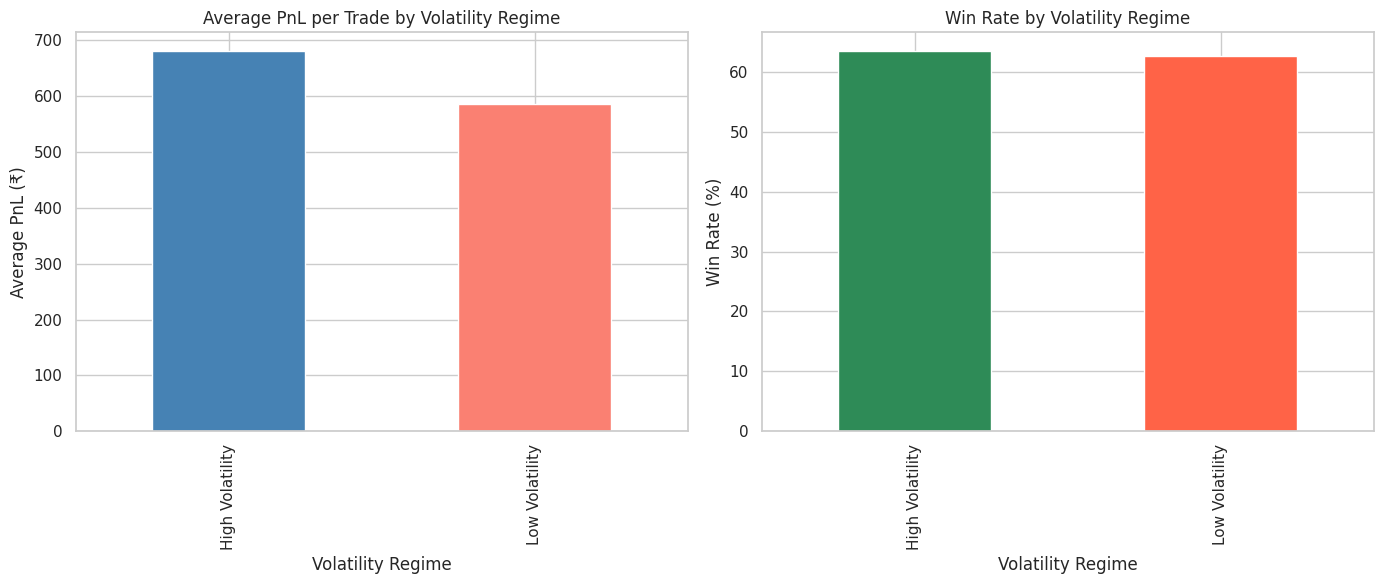

                      Avg PnL     Total PnL  Number of Trades  \
Volatility Regime                                               
High Volatility    680.459840  2.138957e+07             31434   
Low Volatility     585.761037  1.355275e+07             23137   

                   Number of Trades Direction  
Volatility Regime                              
High Volatility                         31463  
Low Volatility                          23149  

Win Rates (%):
Volatility Regime
High Volatility    63.436417
Low Volatility     62.715452
Name: Win, dtype: float64


In [40]:
# 📦 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📂 Load your tradebook
tradebook['Entry Time'] = pd.to_datetime(tradebook['Entry Time'])
tradebook['Exit Time'] = pd.to_datetime(tradebook['Exit Time'])

# 🛠 Prepare data: Create Exit Date
tradebook['Exit Date'] = tradebook['Exit Time'].dt.date

# 🛠 Daily Aggregation
daily = tradebook.groupby('Exit Date').agg({
    'PnL': 'sum',
    'Entry Price': 'mean',
    'Exit Price': ['max', 'min']
})
daily.columns = ['PnL', 'Entry Price', 'Max Exit Price', 'Min Exit Price']

# 📈 Calculate Daily Range % (simple volatility proxy)
daily['Daily Range %'] = (daily['Max Exit Price'] - daily['Min Exit Price']) / daily['Entry Price'] * 100

# 🔥 Define Volatility Clusters
vol_threshold = daily['Daily Range %'].median()
daily['Volatility Regime'] = np.where(daily['Daily Range %'] > vol_threshold, 'High Volatility', 'Low Volatility')

# 🔗 Merge Volatility Regime back to Tradebook
tradebook = tradebook.merge(daily[['Volatility Regime']], left_on=tradebook['Exit Time'].dt.date, right_index=True)

# 📊 Analyze Performance by Volatility
volatility_performance = tradebook.groupby('Volatility Regime').agg({
    'PnL': ['mean', 'sum', 'count'],
    'Direction': 'count'
})
volatility_performance.columns = ['Avg PnL', 'Total PnL', 'Number of Trades', 'Number of Trades Direction']

# 🎯 Win Rate calculation
win_rate = tradebook.assign(Win = tradebook['PnL'] > 0).groupby('Volatility Regime')['Win'].mean() * 100

# 🎨 Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average PnL per Trade
volatility_performance['Avg PnL'].plot(kind='bar', ax=axes[0], title='Average PnL per Trade by Volatility Regime', color=['steelblue', 'salmon'])
axes[0].set_ylabel('Average PnL (₹)')

# Win Rate in each Volatility Regime
win_rate.plot(kind='bar', ax=axes[1], title='Win Rate by Volatility Regime', color=['seagreen', 'tomato'])
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()

# 🖨 Print the table
print(volatility_performance)
print("\nWin Rates (%):")
print(win_rate)


In [41]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import calendar

# Remove trades at exactly 09:15
df = df[df['Entry Time'].dt.time != pd.to_datetime("09:15").time()]

# Sort and calculate metrics
df = df.sort_values('Entry Time')
df['Cumulative PnL'] = df['PnL'].cumsum()
df['Peak'] = df['Cumulative PnL'].cummax()
df['Drawdown'] = ((df['Cumulative PnL'] - df['Peak']) / 1000000) * 100  # % drawdown

# ------------------------------
# 1. Portfolio Balance & Drawdown
# ------------------------------
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Portfolio Balance Over Time", "Drawdown (%)")
)

# Portfolio balance line
fig.add_trace(
    go.Scatter(
        x=df['Entry Time'], y=df['Cumulative PnL'],
        mode='lines+markers',
        name='Balance',
        line=dict(color='purple'),
        text=df['Cumulative PnL'].round(2).astype(str),
        hovertemplate='Date: %{x}<br>Balance: ₹%{text}'
    ),
    row=1, col=1
)

# Drawdown line (already in %)
fig.add_trace(
    go.Scatter(
        x=df['Entry Time'], y=df['Drawdown'],
        mode='lines+markers',
        name='Drawdown (%)',
        line=dict(color='red'),
        text=df['Drawdown'].round(2).astype(str) + '%',
        hovertemplate='Date: %{x}<br>Drawdown: %{text}'
    ),
    row=2, col=1
)

fig.update_layout(
    height=700,
    width=1000,
    title_text="Portfolio Performance Overview",
    template='plotly_white'
)
fig.update_yaxes(title_text="Balance (₹)", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
fig.update_xaxes(title_text="Time", row=2, col=1)

fig.show()

# ------------------------
# 2. Yearly Returns Histogram (%)
# ------------------------
df['Year'] = df['Entry Time'].dt.year
capital = 1000000  # base capital per trade
yearly_returns = df.groupby('Year')['PnL'].sum()
yearly_returns_pct = (yearly_returns / capital) * 100

fig_hist = go.Figure()
fig_hist.add_trace(go.Bar(
    x=yearly_returns_pct.index.astype(str),
    y=yearly_returns_pct.values,
    marker_color='green',
    name='Yearly Returns (%)',
    text=yearly_returns_pct.round(2).astype(str) + '%',
    textposition='outside',
    textfont=dict(size=12)
))

fig_hist.update_layout(
    title="Yearly Returns (%)",
    xaxis_title="Year",
    yaxis_title="Return (%)",
    template='plotly_white',
    width=800,
    height=400
)
fig_hist.show()

# ------------------------
# 3. Monthly Returns Heatmap (%)
# ------------------------
df['Month'] = df['Entry Time'].dt.month
monthly_returns = df.groupby(['Year', 'Month'])['PnL'].sum().unstack(fill_value=0)
monthly_returns_pct = (monthly_returns / capital) * 100

# Ensure all months are present
monthly_returns_pct = monthly_returns_pct.reindex(columns=range(1, 13), fill_value=0)
monthly_returns_pct.columns = [calendar.month_abbr[m] for m in monthly_returns_pct.columns]

# Heatmap with % numbers
heatmap = go.Figure(data=go.Heatmap(
    z=monthly_returns_pct.values,
    x=monthly_returns_pct.columns,
    y=monthly_returns_pct.index.astype(str),
    colorscale='RdBu',
    reversescale=True,
    colorbar_title='Return (%)',
    text=monthly_returns_pct.round(2).astype(str) + '%',
    texttemplate="%{text}",
    hovertemplate='Year: %{y}<br>Month: %{x}<br>Return: %{text}'
))

heatmap.update_layout(
    title="Monthly Returns Heatmap (%)",
    xaxis_title="Month",
    yaxis_title="Year",
    template='plotly_white',
    width=1000,
    height=500
)
heatmap.show()


Output hidden; open in https://colab.research.google.com to view.